In [37]:
import torch # main torch library for tensors, operations etc.
import torchvision # additional library for computer vision providing image datasets, cv models etc.
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
# datasets for the precleaned provided datasets
# transforms for image-processing operations

In [38]:
transform = transforms.ToTensor() 
"""
MNIST images are loaded as image objects and cannot be interpreted. ToTensor() converts each 
image into a python tensor. It creates a usable tool to do this. This tensor follows this 
dimension [channel, height, width] like 1, 28, 28 where 1 is the gray scale channel. It then 
converts the 255 scale mapping out from 0 to 1 for easier optimization.
"""

'\nMNIST images are loaded as image objects and cannot be interpreted. ToTensor() converts each \nimage into a python tensor. It creates a usable tool to do this. This tensor follows this \ndimension [channel, height, width] like 1, 28, 28 where 1 is the gray scale channel. It then \nconverts the 255 scale mapping out from 0 to 1 for easier optimization.\n'

# Load the training Data

In [39]:
train_dataset = datasets.MNIST( # creates a custom class with input (image) and label
    root = "data", # where to save or find MNIST on the computer
    train = True, # decide which data is for training and which is for test
    download = True, # download the dataset so I don't need to repeatedly do that
    transform = transform # convert the image into a pytorch tensor
)


In [40]:
# looking at a specific example of a data entry

image, label = train_dataset[0] # not tabular data really just indexed input with label

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Label:", label)
print("Label type:", type(label))

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([1, 28, 28])
Label: 5
Label type: <class 'int'>


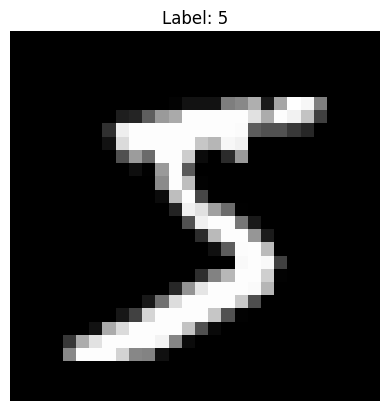

In [41]:
plt.imshow(image.squeeze(), cmap="gray") # displays the numerical pixel value as an image
# the squeeze() changes the (1, 28, 28) to (28, 28)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [42]:
test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
) # creates the testing dataset


Splitting data into Training and Validation Set

In [43]:
from torch.utils.data import random_split, DataLoader

train_size = 54_000
validation_size = 6_000

train_subset, validation_subset = random_split(
    train_dataset,
    [train_size, validation_size],
    generator = torch.Generator().manual_seed(42)
)

batch_size = 64
# give the model 64 examples at a time

train_loader = DataLoader(
    train_subset,
    batch_size = batch_size,
    shuffle = True
)

validation_subset_loader = DataLoader( # validation dataloader
    validation_subset,
    batch_size = batch_size,
    shuffle = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size = batch_size,
    shuffle = True
)

# dataloaders important for data augmentations, shuffling and batch variation to be more robust

In [44]:
images, labels = next(iter(train_loader))

# inspecting each individual batch size

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("First 10 labels:", labels[:10])

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])
First 10 labels: tensor([3, 4, 9, 9, 0, 5, 5, 3, 7, 7])


Next step is to flatten the image for the MLP as it expects a vector input.

In [45]:
flattened_images = images.flatten(start_dim=1)

# images is the whole batch of 64 from the dataloader going from images[0] to images[63]
# every batch would get processed each time before going through all batches
# this was only used an example but in the real process we do it through and through

print("Before flattening:", images.shape)
print("After flattening:", flattened_images.shape)

Before flattening: torch.Size([64, 1, 28, 28])
After flattening: torch.Size([64, 784])


In [46]:
import torch.nn as nn

model = nn.Sequential( # container where there is a sequence of actions in this neural network
    nn.Flatten(),
    nn.Linear(784, 128), # hidden layer
    nn.ReLU(), # activation function
    nn.Linear(128, 10) # output layer
)

# defines the architecture for the neural network

Testing this on a single batch

In [47]:
logits = model(images)

print("Input shape:", images.shape)
print("Output shape:", logits.shape)
print("First image logits:", logits[0])

# produces logits of the 10 numbers and the highest score is most likely to have the number
# this corresponds to tensor(2) and has not learned anything yet so it's not confidently correct

Input shape: torch.Size([64, 1, 28, 28])
Output shape: torch.Size([64, 10])
First image logits: tensor([-0.1133,  0.0040,  0.1016,  0.0675, -0.2284,  0.0787,  0.0152,  0.0756,
        -0.1966, -0.1604], grad_fn=<SelectBackward0>)


In [48]:
# defining and using the loss function

loss_fn = nn.CrossEntropyLoss()

loss = loss_fn(logits, labels)

print("Loss:", loss.item())

# Average loss for one batch of 64 images, calculated using one forward pass.

Loss: 2.3250436782836914


# Choosing the Optimizer

In [49]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

# changing the weights and biases in a direction to reduce loss


In [50]:
optimizer.zero_grad() # clears gradient over from previous iteration otherwise the gradients would accumulate

logits = model(images) # forward pass

loss = loss_fn(logits, labels) # measure the loss

loss.backward() # performs the backpropagation, the answers are stored as gradients inside model parameters

optimizer.step() # uses gradient to update the model's weight and bias

print("Batch loss before update:", loss.item())

# completing one full iteration of a single batch

Batch loss before update: 2.3250436782836914


In [51]:
# check whether the weight update improved the batch

before_update_loss = loss.item()

with torch.no_grad(): # only checking the model don't construct a computational graph
    updated_logits = model(images)
    after_update_loss = loss_fn(updated_logits, labels)

print("Loss before update:", before_update_loss)
print("Loss after update:", after_update_loss.item())

Loss before update: 2.3250436782836914
Loss after update: 2.320345163345337


In [52]:
# we manually trained on one batch for experimentation now to ensue the full training loop so we need a clean model

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

print("Model and optimizer reset.")

Model and optimizer reset.


In [53]:
model.train() # the model put into training mode

total_loss = 0 # initializes loss tracker before the accumulated loss

for batch_number, (images, labels) in enumerate(train_loader): # loop through the training data in dataloader each iter produces image, label

    optimizer.zero_grad()

    logits = model(images)

    loss = loss_fn(logits, labels)

    loss.backward()

    optimizer.step()

    total_loss += loss.item()

""" 
For each loop we go through each batch of 64 where we zero the gradient do the forward pass, calculate the loss, backprop, update weights.
Each batch starts off with the previous weights and aims to reduce the loss associated with the weights.
"""

average_loss = total_loss / len(train_loader)

print("Number of batches:", len(train_loader))
print("Average training loss:", average_loss)
# summary of how the model performed throughout the entire epoche

Number of batches: 844
Average training loss: 1.2924886948265735


In [54]:
# using current weights, how well does it perform on 6,000 validation images it was not trained on

model.eval()

total_validation_loss = 0
correct_predictions = 0
total_examples = 0

with torch.no_grad(): # this because during training you need to remember every operation so back prop is needed but evaluation does not need this step

    for images, labels in validation_subset_loader:

        logits = model(images) # raw unormalized predictors of each multi class

        loss = loss_fn(logits, labels)

        total_validation_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1) # converts raw numeric output into a real final discrete class predictor

        correct_predictions += (predictions == labels).sum().item()

        total_examples += labels.size(0)

average_validation_loss = total_validation_loss / total_examples
validation_accuracy = correct_predictions / total_examples

print("Validation loss:", average_validation_loss)
print("Validation accuracy:", validation_accuracy)

"""
The reason why the loss is much larger with the training compared to the validation because it contains the beginning where the model was very poor using arbitrary model
parameters to measure thus the loss of the cross entropy is gonna be high compared to here where the model is already refined.

Cross-loss entropy = -log(P_correct class), so 0.659 is near the loss associated with assigning roughly 50% probability to the correct class. This is approximately the mean
probability assigned to the true class across the validation set. 

Next step is to run multiple epoches to see if the model performs better or if it just overfits.
"""

Validation loss: 0.6563272501627604
Validation accuracy: 0.8528333333333333


'\nThe reason why the loss is much larger with the training compared to the validation because it contains the beginning where the model was very poor using arbitrary model\nparameters to measure thus the loss of the cross entropy is gonna be high compared to here where the model is already refined.\n\nCross-loss entropy = -log(P_correct class), so 0.659 is near the loss associated with assigning roughly 50% probability to the correct class. This is approximately the mean\nprobability assigned to the true class across the validation set. \n\nNext step is to run multiple epoches to see if the model performs better or if it just overfits.\n'

In [ ]:
# running the second epoche on the current model to see if it improves
# this starts batch 1 of epoche 2 using the weights learned at the end of epoche 2

model.train()

total_loss = 0
total_training_examples = 0

for images, labels in train_loader:

    optimizer.zero_grad()

    logits = model(images)

    loss = loss_fn(logits, labels)

    loss.backward()

    optimizer.step()

    total_loss += loss.item() * images.size(0)
    total_training_examples += images.size(0)

average_training_loss = total_loss / total_training_examples

# overfitting comes from the comparison between the validation loss and the training loss where if the training loss is a lot smaller compared to validation overfitting
# more fitting means converging at a smaller loss 

print("Epoch 2 training loss:", average_training_loss)

Epoch 2 training loss: 0.5204143476132993
